# Random Forests on Census Income Dataset

This notebook demonstrates how to use the reusable `RandomForest` functions
from `src/rice_ml/supervised_learning/random_forests.py` on the
`census_income.csv` dataset.


In [3]:
import pathlib
import sys

import pandas as pd
from sklearn.model_selection import train_test_split

# Point to project root (INDE-577-FINAL-PROJECT)
project_root = pathlib.Path().resolve().parents[2]

# Make src importable
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from rice_ml.supervised_learning.random_forests import (
    RandomForestConfig,
    train_random_forest,
    predict_random_forest,
    evaluate_random_forest,
    get_feature_importances,
)

project_root


WindowsPath('C:/Users/mritu/Desktop/577-Project/INDE-577-Final-Project')

In [2]:
import pandas as pd
import sklearn
import matplotlib
print("All good!")

All good!


In [4]:
data_path = project_root / "datasets" / "census_income.csv"
df = pd.read_csv(data_path)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [11]:
target_col = "income" 

X = df.drop(columns=[target_col, "fnlwgt"])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((39073, 99), (9769, 99))

In [12]:
config = RandomForestConfig(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)

model = train_random_forest(X_train, y_train, config)
model


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
#Evaluation of Model

results = evaluate_random_forest(model, X_test, y_test)

print("Accuracy:", results["accuracy"])
print("\nClassification Report:\n")
print(results["classification_report"])
print("\nConfusion Matrix:\n")
print(results["confusion_matrix"])


Accuracy: 0.8502405568635479

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      7431
        >50K       0.71      0.63      0.67      2338

    accuracy                           0.85      9769
   macro avg       0.80      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769


Confusion Matrix:

[[6830  601]
 [ 862 1476]]


In [14]:
importances = get_feature_importances(model, X.columns.tolist())
importances.head(20)


,feature,importance
0,age,0.240151
1,hours_per_week,0.118729
2,capital_gain,0.107328
3,marital_status_Married-civ-spouse,0.083358
4,education_num,0.067722
5,capital_loss,0.036463
6,marital_status_Never-married,0.035014
7,occupation_Exec-managerial,0.019618
8,sex_Male,0.019120
9,relationship_Not-in-family,0.018564


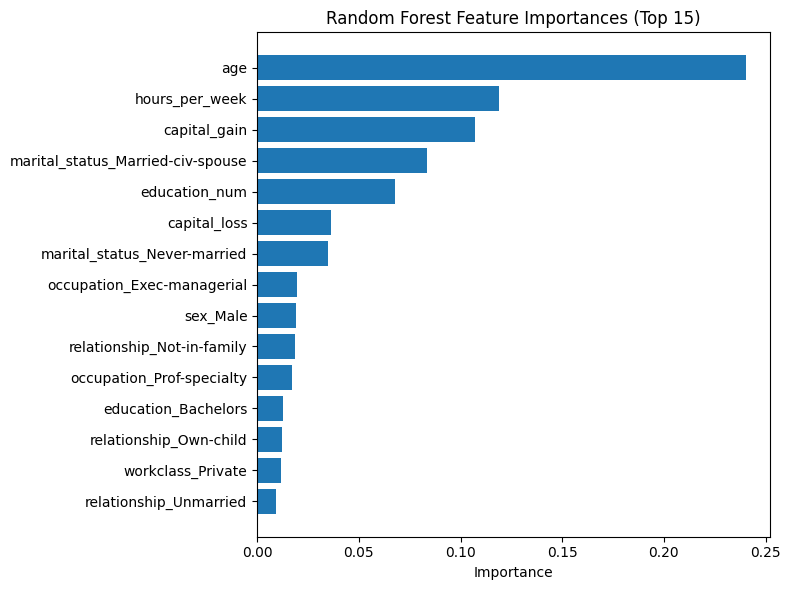

In [15]:
import matplotlib.pyplot as plt

top_k = 15
top = importances.head(top_k).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.xlabel("Importance")
plt.title(f"Random Forest Feature Importances (Top {top_k})")
plt.tight_layout()
plt.show()
